**Background**

The purpose of this notebook is to create and document a dataloader for our Volume 3 Project. The original dataset we selected while very convenient had a significant weakness in that none of the light curves had ID's which could be correlated with other ground truth data. As such found another dataset which contained lots of ground truth data we could use to analyze the effectiveness of our learning experiments and node ID's which we could use in concert with the lightKurve package to pull data from NASA's Kepler and TESS planet hunting telescopes. 

**Method**

The first step is to pull the ground truth dataset from Kaggle. This dataset posted by NASA contains information on more than 10,000 exoplanet candidates that Kepler has observed.
For information on the columns of this dataset please see: https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html

This notebook assumes that you have downloaded, unzipped and saved the file in a folder called GT.

In [10]:
import pandas as pd

In [11]:
# Update this line to reflect the directory in which you have the repo
%cd C:\Users\Jared\Desktop\Vol3_project
# Everything from here should stay the same
path = "ACME_VOL3_PLANET_FINDER/GT/cumulative.csv"
df = pd.read_csv(path, delimiter=',')

C:\Users\Jared\Desktop\Vol3_project


We'll take a look at the first 10 columns

In [3]:
df.head(10)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
6,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
7,8,10872983,K00756.03,Kepler-228 b,CONFIRMED,CANDIDATE,0.992,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
8,9,6721123,K00114.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-124.0,3.986,0.182,-0.098,1.958,0.322,-0.483,298.86435,42.151569,12.660
9,10,10910878,K00757.01,Kepler-229 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-83.0,4.485,0.083,-0.028,0.848,0.033,-0.072,286.99948,48.375790,15.841


Note that the first two rows share the same kepid, this is because the kepid corrosponds to the observed star and the kepler_name corrosponds to the planet candidate. Other columns relate to the status of the planet candidate, scientists confidence, and attributes of the suspected planet. 

Since we're going to be pulling lightcurves using the kepid we check that all every row has one. We'll also count how many unique light curves we will pull.

In [4]:
missing = df['kepid'].isnull().sum()
print(f'Num missing {missing}')
unique = df['kepid'].nunique()
print(f"Num unique {unique}")

Num missing 0
Num unique 8214


Because this is our ground truth dataset we won't do any cleaning beyound making sure that each row has a kepid. 

Our next step is to create a dictionary where each key is the kepid and the value is the observed lightcurve


In [6]:
# Here is some example code to see how things work
from lightkurve import search_targetpixelfile
pixelfile = search_targetpixelfile("KIC 8462852", quarter=16).download()

c:\Users\Jared\Desktop\Vol3_project\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


The code above loaded an object that contains a section of the images taken by the Kepler mission, the section contains the star we specified in the search_targetpixelfile. 

<Axes: title={'center': 'Target ID: 8462852, Cadence: 66714'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

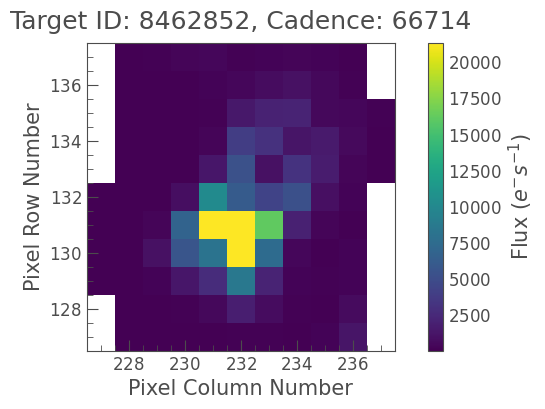

In [7]:
# Here we plot the image
%matplotlib inline
pixelfile.plot(frame=1)

While these images are pretty cool, and could be used for some visual machine learning techniques, for now we simply want the lightcurve, which is essentially the sum of all the pixels in the image patch.

In [8]:
lc = pixelfile.to_lightcurve(aperture_mask='all')

lc is a lightcurve object which has several usefull attributes for our purposes we care the most about .time (when the measurements were made in units of days) and .flux (the "brightness" measured in electrons per second)

In [9]:
print(lc.time)
print(lc.flux)

[1472.11777934 1472.13821223 1472.15864492 ... 1557.91762194 1557.9380561
 1557.95849016]
[258645.03 258660.05 258690.08 ... 258948.84 258884.66 258865.6 ] electron / s


lightcurve objects also have a built in plot method

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

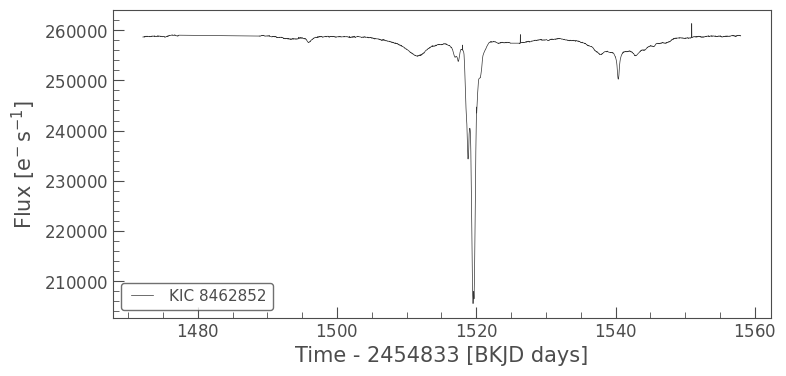

In [10]:
lc.plot()

lc objects also contain information about errors/uncertainty in measurements

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

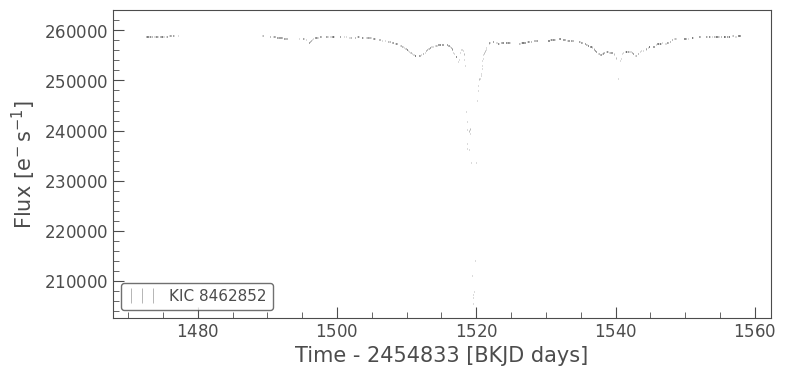

In [11]:
lc.errorbar(alpha=0.5)

Now we are ready to extract and store the lightcurves corrosponding to each of the 8214 unique Kepler ids in our dataset. To begin with we don't want the full pixel data, so we'll simply use search_lightcurve instead.

In [ ]:
from lightkurve import search_lightcurve
import numpy as np
import joblib

There is an added complication, because Kepler orbited the sun it was forced to reposition every 93 days to keep its solar panels in line. This means that every 93 days the ccd that was analyzing a particular star may have switched, due to statistical hardware differences the lightcurves are thusly seperated by quaters (93 day increments).
We can't simply paste all quarters together due to these differences

It turns out that even though each light curve object is realatively small, downloading all quarters of all of them is unfeasible. As such we'll start off with a randomly chosen subset of size 100. We also use joblib to compress and save the resulting dictionary. 

**This code takes an extremely long time to run**

!!!!!

**Q0 is actually only a test run and contains very little data, don't download it**

In [ ]:

subset_collectionq1 = {}
# Given the slowness of the download we start with only a random subset
for kid in np.random.choice(df['kepid'].unique(), size=100, replace=False):
    # The try and except is for larger downloads that might have network troubles
    try:
        print(f"ID {kid}")
        lc = search_lightcurve(f"KIC {kid}", quarter=1)
        # Only download if data was found
        if len(lc) > 0:
            collection = lc.download_all()
            subset_collectionq1[kid] = collection
        else:
            print(f"No data")
    except Exception as e:
        print(f"{kid} failed. Error {e}")


ID 5097470
ID 6933781
ID 7811211
ID 9697131
ID 2445154
ID 4275721
ID 9221517
ID 3858879
ID 8483021
No data
ID 9269281
No data
ID 7017437
ID 5037742
ID 3002478
ID 9307509
ID 8265990
ID 5880320
ID 6347434
ID 10290666
ID 11599264
No data
ID 9576197
ID 7625143
ID 1865864
No data
ID 7684873
ID 6936966
ID 10026457
ID 9118858
No data
ID 6949550
ID 6546528
ID 11911580
ID 4750406
ID 3438975
ID 8409295
ID 3097926
No data
ID 5640085
ID 8098212
ID 9353314
ID 9595956
No data
ID 5389540
No data
ID 11076276
ID 4571004
ID 12504988
ID 10875007
ID 11598894
ID 10285631
ID 8956706
No data
ID 8975776
ID 8866102
ID 2437112
2437112 failed. Error Not recognized as a supported data product:
C:\Users\Jared\.lightkurve\cache\mastDownload\HLSP\hlsp_iris_kepler_kepler_kplr002437112-stitched_kepler_v1.0_lc\hlsp_iris_kepler_kepler_kplr002437112-stitched_kepler_v1.0_lc.fits
This file may be corrupt due to an interrupted download. Please remove it from your disk and try again.
ID 4255422
ID 9851226
ID 7902719
ID 98519

Now that we have a dictionary of lightcurves, we want to extract the data we care about and save it in a format that is easier to transmit. 

In [16]:
simple_data_q1 = {}

for kid, collection in subset_collectionq1.items():
    lc = collection[0]
    # This extracts the values as numpy arrays
    simple_data_q1[kid] = {'time': lc.time.value, 'flux': lc.flux.value,'flux_err': lc.flux_err.value}
joblib.dump(simple_data_q1, 'subset_q1.joblib', compress=3)
print("File saved")

File saved


Code to load the finished dictionary

In [18]:
light_curve_dict = joblib.load("subset_q1.joblib")

In [20]:
print(light_curve_dict.keys())

dict_keys([np.int64(5097470), np.int64(6933781), np.int64(7811211), np.int64(9697131), np.int64(2445154), np.int64(4275721), np.int64(9221517), np.int64(3858879), np.int64(7017437), np.int64(5037742), np.int64(3002478), np.int64(9307509), np.int64(8265990), np.int64(5880320), np.int64(6347434), np.int64(10290666), np.int64(9576197), np.int64(7625143), np.int64(7684873), np.int64(6936966), np.int64(10026457), np.int64(6949550), np.int64(6546528), np.int64(11911580), np.int64(4750406), np.int64(3438975), np.int64(8409295), np.int64(5640085), np.int64(8098212), np.int64(9353314), np.int64(11076276), np.int64(4571004), np.int64(12504988), np.int64(10875007), np.int64(11598894), np.int64(10285631), np.int64(8975776), np.int64(8866102), np.int64(4255422), np.int64(9851226), np.int64(7902719), np.int64(9851943), np.int64(10904004), np.int64(8367113), np.int64(10552151), np.int64(5384079), np.int64(6222898), np.int64(3937814), np.int64(8581658), np.int64(9716028), np.int64(12304728), np.int64(